In [1]:
# Install required libraries (run once)
!pip install geopandas pysal libpysal esda splot pygeohash folium matplotlib seaborn scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.4 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Geospatial
import geopandas as gpd
from shapely.geometry import Point

# Spatial statistics
import libpysal
from libpysal.weights import KNN, Queen
import esda
from esda.moran import Moran, Moran_Local

# Feature engineering helpers
import pygeohash as pgh
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import BallTree

# Suppress matplotlib warnings
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

print('All libraries loaded successfully.')

All libraries loaded successfully.


Data Loading & Initial AUdit

In [3]:
# ---------------------------------------------------------------
# UPDATE THIS PATH to where you stored the CSV after downloading
# from Kaggle: https://www.kaggle.com/datasets/sobhanmoosavi/us-weather-events
DATA_PATH = 'WeatherEvents_Jan2016-Dec2022.csv'
# ---------------------------------------------------------------

# Load with low_memory=False to avoid dtype warnings on mixed columns
df = pd.read_csv(DATA_PATH, low_memory=False)

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')

Shape: (512229, 14)
Columns: ['EventId', 'Type', 'Severity', 'StartTime(UTC)', 'EndTime(UTC)', 'Precipitation(in)', 'TimeZone', 'AirportCode', 'LocationLat', 'LocationLng', 'City', 'County', 'State', 'ZipCode']


In [4]:
# --- 1.1 Basic audit ---
print('=== Data Types ===')
print(df.dtypes)
print('\n=== First 3 rows ===')
df.head(3)

=== Data Types ===
EventId               object
Type                  object
Severity              object
StartTime(UTC)        object
EndTime(UTC)          object
Precipitation(in)    float64
TimeZone              object
AirportCode           object
LocationLat          float64
LocationLng          float64
City                  object
County                object
State                 object
ZipCode              float64
dtype: object

=== First 3 rows ===


,EventId,Type,Severity,StartTime(UTC),EndTime(UTC),Precipitation(in),TimeZone,AirportCode,LocationLat,LocationLng,City,County,State,ZipCode
0,W-1,Snow,Light,2016-01-06 23:14:00,2016-01-07 00:34:00,0.00,US/Mountain,K04V,38.0972,-106.1689,Saguache,Saguache,CO,81149.0
1,W-2,Snow,Light,2016-01-07 04:14:00,2016-01-07 04:54:00,0.00,US/Mountain,K04V,38.0972,-106.1689,Saguache,Saguache,CO,81149.0
2,W-3,Snow,Light,2016-01-07 05:54:00,2016-01-07 15:34:00,0.03,US/Mountain,K04V,38.0972,-106.1689,Saguache,Saguache,CO,81149.0


Columns with missing values:
                   Missing Count  Missing %
ZipCode                     6544       1.28
City                        3637       0.71
StartTime(UTC)                 1       0.00
Precipitation(in)              1       0.00
EndTime(UTC)                   1       0.00
TimeZone                       1       0.00
AirportCode                    1       0.00
LocationLng                    1       0.00
LocationLat                    1       0.00
County                         1       0.00
State                          1       0.00


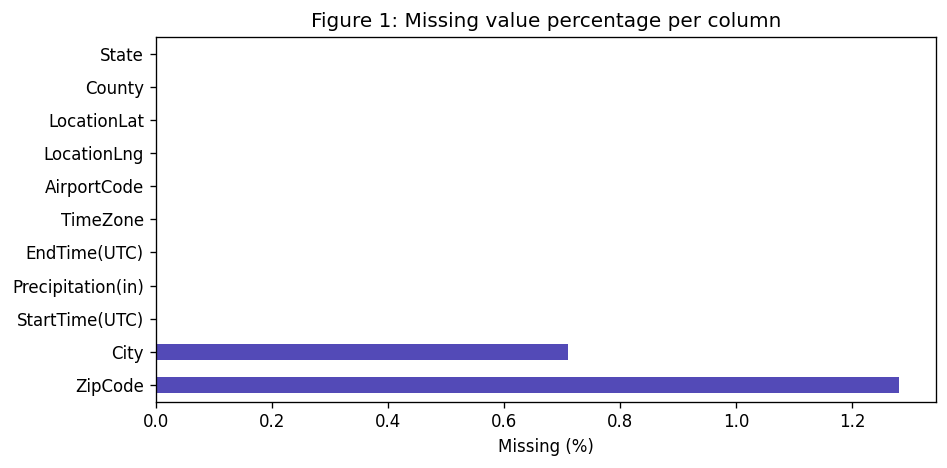

In [5]:
# --- 1.2 Missing value audit ---
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
audit = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
audit = audit[audit['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print('Columns with missing values:')
print(audit)

# Visualise
if not audit.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    audit['Missing %'].plot(kind='barh', ax=ax, color='#534AB7')
    ax.set_xlabel('Missing (%)')
    ax.set_title('Figure 1: Missing value percentage per column')
    plt.tight_layout()
    plt.savefig('fig1_missing_values.png', bbox_inches='tight')
    plt.show()

=== Weather Event Type distribution ===
Type
Rain             287408
Fog              115222
Snow              82776
Cold              13154
Precipitation      9189
Storm              4265
Hail                215
Name: count, dtype: int64

=== Severity distribution ===
Severity
Light       305645
Severe      100734
Moderate     82884
Heavy        13561
UNK           9189
Other          215
L                1
Name: count, dtype: int64

=== TimeZone distribution ===
TimeZone
US/Central     200707
US/Eastern     191398
US/Mountain     62115
US/Pacific      58008
Name: count, dtype: int64


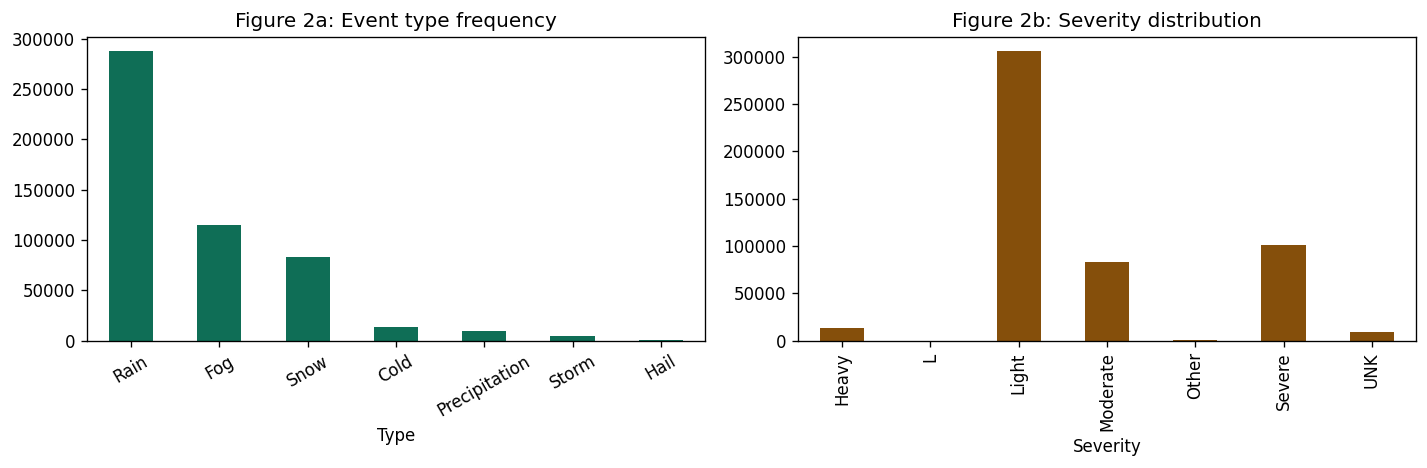

In [6]:
# --- 1.3 Target column distributions ---
print('=== Weather Event Type distribution ===')
print(df['Type'].value_counts())

print('\n=== Severity distribution ===')
print(df['Severity'].value_counts())

print('\n=== TimeZone distribution ===')
print(df['TimeZone'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['Type'].value_counts().plot(kind='bar', ax=axes[0], color='#0F6E56')
axes[0].set_title('Figure 2a: Event type frequency')
axes[0].tick_params(axis='x', rotation=30)

df['Severity'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='#854F0B')
axes[1].set_title('Figure 2b: Severity distribution')
plt.tight_layout()
plt.savefig('fig2_distributions.png', bbox_inches='tight')
plt.show()

Data Cleaning & Spatial Column Preparation

In [7]:
# --- 2.1 Drop rows where spatial coordinates are missing (required for all spatial work) ---
df_clean = df.dropna(subset=['LocationLat', 'LocationLng']).copy()
print(f'Rows after dropping null coordinates: {len(df_clean):,} (dropped {len(df) - len(df_clean):,})')

# Rename for convenience
df_clean = df_clean.rename(columns={'LocationLat': 'lat', 'LocationLng': 'lng'})

# Parse timestamps
df_clean['StartTime(UTC)'] = pd.to_datetime(df_clean['StartTime(UTC)'], utc=True)
df_clean['EndTime(UTC)']   = pd.to_datetime(df_clean['EndTime(UTC)'], utc=True)

# Compute event duration in minutes
df_clean['duration_min'] = (
    (df_clean['EndTime(UTC)'] - df_clean['StartTime(UTC)'])
    .dt.total_seconds() / 60
).clip(lower=0)  # remove negative durations (data errors)

print(f'Duration stats (minutes):\n{df_clean["duration_min"].describe()}')

Rows after dropping null coordinates: 512,228 (dropped 1)
Duration stats (minutes):
count    512228.000000
mean         89.222909
std        1963.813358
min           0.000000
25%          20.000000
50%          40.000000
75%          80.000000
max      986282.000000
Name: duration_min, dtype: float64


In [8]:
# --- 2.2 Validate coordinate ranges (CONUS bounding box) ---
lat_ok  = df_clean['lat'].between(24.0, 50.0)
lng_ok  = df_clean['lng'].between(-125.0, -66.0)
df_clean = df_clean[lat_ok & lng_ok].copy()
print(f'Rows after CONUS bounding box filter: {len(df_clean):,}')

Rows after CONUS bounding box filter: 512,228


In [9]:
# --- 2.3 Optional: sample for fast prototyping (comment out for full run) ---
# For a 3-member team running on a laptop, 500k rows is comfortable
# SAMPLE_SIZE = 500_000
# df_clean = df_clean.sample(n=SAMPLE_SIZE, random_state=42).copy()
# print(f'Working with sample of {len(df_clean):,} rows')

df_clean = df_clean.reset_index(drop=True)
print(f'Final working dataframe: {df_clean.shape}')

Final working dataframe: (512228, 15)


Spatial Feature Engineering

In [10]:
# --- 3.1 Geohash encoding (precision 4 ≈ 39km x 20km cell, precision 5 ≈ 4.9km x 4.9km) ---
df_clean['geohash4'] = df_clean.apply(
    lambda r: pgh.encode(r['lat'], r['lng'], precision=4), axis=1
)
df_clean['geohash5'] = df_clean.apply(
    lambda r: pgh.encode(r['lat'], r['lng'], precision=5), axis=1
)

print(f'Unique geohash-4 cells: {df_clean["geohash4"].nunique():,}')
print(f'Unique geohash-5 cells: {df_clean["geohash5"].nunique():,}')

Unique geohash-4 cells: 125
Unique geohash-5 cells: 126


In [11]:
# --- 3.2 Distance from CONUS geographic centroid (approx. geographic center of contiguous US) ---
# Geographic center of contiguous US: ~39.5°N, 98.35°W
CONUS_LAT, CONUS_LNG = 39.5, -98.35

def haversine_km(lat1, lon1, lat2, lon2):
    """Compute great-circle distance in km using Haversine formula."""
    R = 6371.0  # Earth radius in km
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi   = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlambda/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

df_clean['dist_to_centroid_km'] = haversine_km(
    df_clean['lat'].values, df_clean['lng'].values,
    CONUS_LAT, CONUS_LNG
)

print(df_clean['dist_to_centroid_km'].describe())

count    512228.000000
mean       1294.989666
std         604.724340
min         162.496286
25%         748.290025
50%        1192.070747
75%        1831.954665
max        2573.403959
Name: dist_to_centroid_km, dtype: float64


In [12]:
# --- 3.3 State label encoding ---
le_state = LabelEncoder()
df_clean['state_id'] = le_state.fit_transform(df_clean['State'].fillna('Unknown'))

# --- 3.4 Event type encoding ---
le_type = LabelEncoder()
df_clean['type_id'] = le_type.fit_transform(df_clean['Type'])

# --- 3.5 Severity numeric (already numeric; fill NaN with mode) ---
severity_mode = df_clean['Severity'].mode()[0]
df_clean['severity_num'] = df_clean['Severity'].fillna(severity_mode)

print('Encoded columns added: state_id, type_id, severity_num')

Encoded columns added: state_id, type_id, severity_num


Cell event count range: 119 – 9914


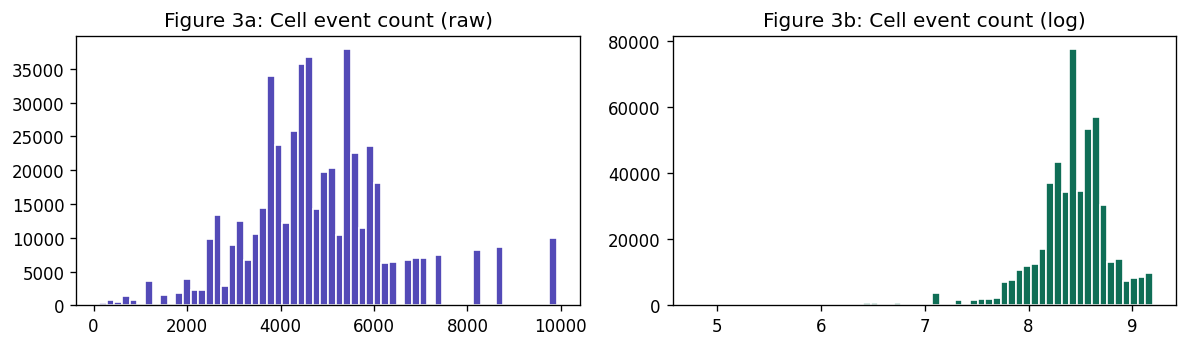

In [13]:
# --- 3.6 Spatial density feature: events per geohash-4 cell ---
cell_counts = df_clean['geohash4'].value_counts().rename('cell_event_count')
df_clean = df_clean.join(cell_counts, on='geohash4')

print(f'Cell event count range: {df_clean["cell_event_count"].min()} – {df_clean["cell_event_count"].max()}')

# Log-transform (heavy right skew)
df_clean['log_cell_density'] = np.log1p(df_clean['cell_event_count'])

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(df_clean['cell_event_count'], bins=60, color='#534AB7', edgecolor='white')
axes[0].set_title('Figure 3a: Cell event count (raw)')
axes[1].hist(df_clean['log_cell_density'], bins=60, color='#0F6E56', edgecolor='white')
axes[1].set_title('Figure 3b: Cell event count (log)')
plt.tight_layout()
plt.savefig('fig3_cell_density.png', bbox_inches='tight')
plt.show()

In [14]:
# --- 3.7 Mean severity per geohash-4 cell (spatial context feature) ---

# Explanation of the error:
# The error "TypeError: agg function failed [how->mean,dtype->object]" occurs because
# the 'severity_num' column, which is used to calculate the mean, is currently
# of 'object' (string) data type. Pandas cannot compute the mean of strings.
# This column was created in a previous step by filling NaN values in the original
# 'Severity' column (which contains string categories like 'Light', 'Moderate', etc.)
# and was not converted to a numeric type.

# Fix: Convert the 'Severity' column to numeric values.
# Define a mapping for severity levels to numerical values.
severity_mapping = {
    'Light': 1,
    'Moderate': 2,
    'Severe': 3,
    'Heavy': 4,
    'UNK': 0,      # Assign 0 for unknown severity
    'Other': 0     # Assign 0 for other/unspecified severity
}

# Re-create 'severity_num' as a numeric column by mapping the 'Severity' column.
# First, handle any NaNs in the original 'Severity' column (assuming 'Light' as mode, as in previous logic).
df_clean['severity_num'] = df_clean['Severity'].fillna('Light').map(severity_mapping).astype(int)

# Now, with 'severity_num' as a numeric column, the mean can be calculated.
cell_severity = df_clean.groupby('geohash4')['severity_num'].mean().rename('mean_cell_severity')
df_clean = df_clean.join(cell_severity, on='geohash4')

print('Mean cell severity stats:')
print(df_clean['mean_cell_severity'].describe())

Mean cell severity stats:
count    512228.000000
mean          1.616192
std           0.201665
min           0.603448
25%           1.504745
50%           1.595847
75%           1.687181
max           2.530655
Name: mean_cell_severity, dtype: float64


In [15]:
# --- 3.8 Timezone zone as ordinal proximity-to-coast proxy ---
# Eastern=1 (coastal), Central=2, Mountain=3, Pacific=4 (coastal)
tz_map = {'US/Eastern': 1, 'US/Central': 2, 'US/Mountain': 3, 'US/Pacific': 4}
df_clean['tz_ordinal'] = df_clean['TimeZone'].map(tz_map).fillna(0).astype(int)

print('TimeZone ordinal encoding:')
print(df_clean['tz_ordinal'].value_counts())

TimeZone ordinal encoding:
tz_ordinal
2    200707
1    191398
3     62115
4     58008
Name: count, dtype: int64


In [16]:
# --- 3.9 Spatial lag feature using BallTree (k=10 nearest neighbours) ---
# For efficiency, compute on a sample if dataset is large
# This gives: for each point, mean severity of its 10 nearest spatial neighbours

print('Computing spatial lag (k-NN severity)... this may take a few minutes on full data.')

coords_rad = np.radians(df_clean[['lat', 'lng']].values)
tree = BallTree(coords_rad, metric='haversine')

K = 10
indices = tree.query(coords_rad, k=K+1, return_distance=False)  # k+1 to exclude self
# Exclude the point itself (first column = self)
neighbour_indices = indices[:, 1:]

severity_arr = df_clean['severity_num'].values
df_clean['spatial_lag_severity'] = np.mean(severity_arr[neighbour_indices], axis=1)

print('Spatial lag severity stats:')
print(df_clean['spatial_lag_severity'].describe())

Computing spatial lag (k-NN severity)... this may take a few minutes on full data.
Spatial lag severity stats:
count    512228.000000
mean          1.622238
std           0.434591
min           0.300000
25%           1.300000
50%           1.600000
75%           1.900000
max           3.000000
Name: spatial_lag_severity, dtype: float64


In [17]:
# --- Summary of all engineered spatial features ---
spatial_features = [
    'lat', 'lng',
    'geohash4', 'geohash5',
    'dist_to_centroid_km',
    'state_id', 'type_id', 'severity_num',
    'cell_event_count', 'log_cell_density',
    'mean_cell_severity',
    'tz_ordinal',
    'spatial_lag_severity',
    'duration_min'
]

print('=== Engineered Spatial Feature Summary ===')
print(df_clean[spatial_features].describe().round(3))

=== Engineered Spatial Feature Summary ===
              lat         lng  dist_to_centroid_km    state_id     type_id  \
count  512228.000  512228.000           512228.000  512228.000  512228.000   
mean       39.799     -93.013             1294.990      20.992       3.382   
std         5.117      14.513              604.724      12.005       1.506   
min        26.538    -122.864              162.496       0.000       0.000   
25%        36.426    -102.406              748.290      11.000       1.000   
50%        40.668     -91.575             1192.071      21.000       4.000   
75%        43.642     -81.757             1831.955      30.000       4.000   
max        48.884     -68.018             2573.404      42.000       6.000   

       severity_num  cell_event_count  log_cell_density  mean_cell_severity  \
count    512228.000        512228.000        512228.000          512228.000   
mean          1.616          4826.883             8.421               1.616   
std           0.9

Spatial EDA Exploratory Ananlysis

Nationalwide Scaterr Map

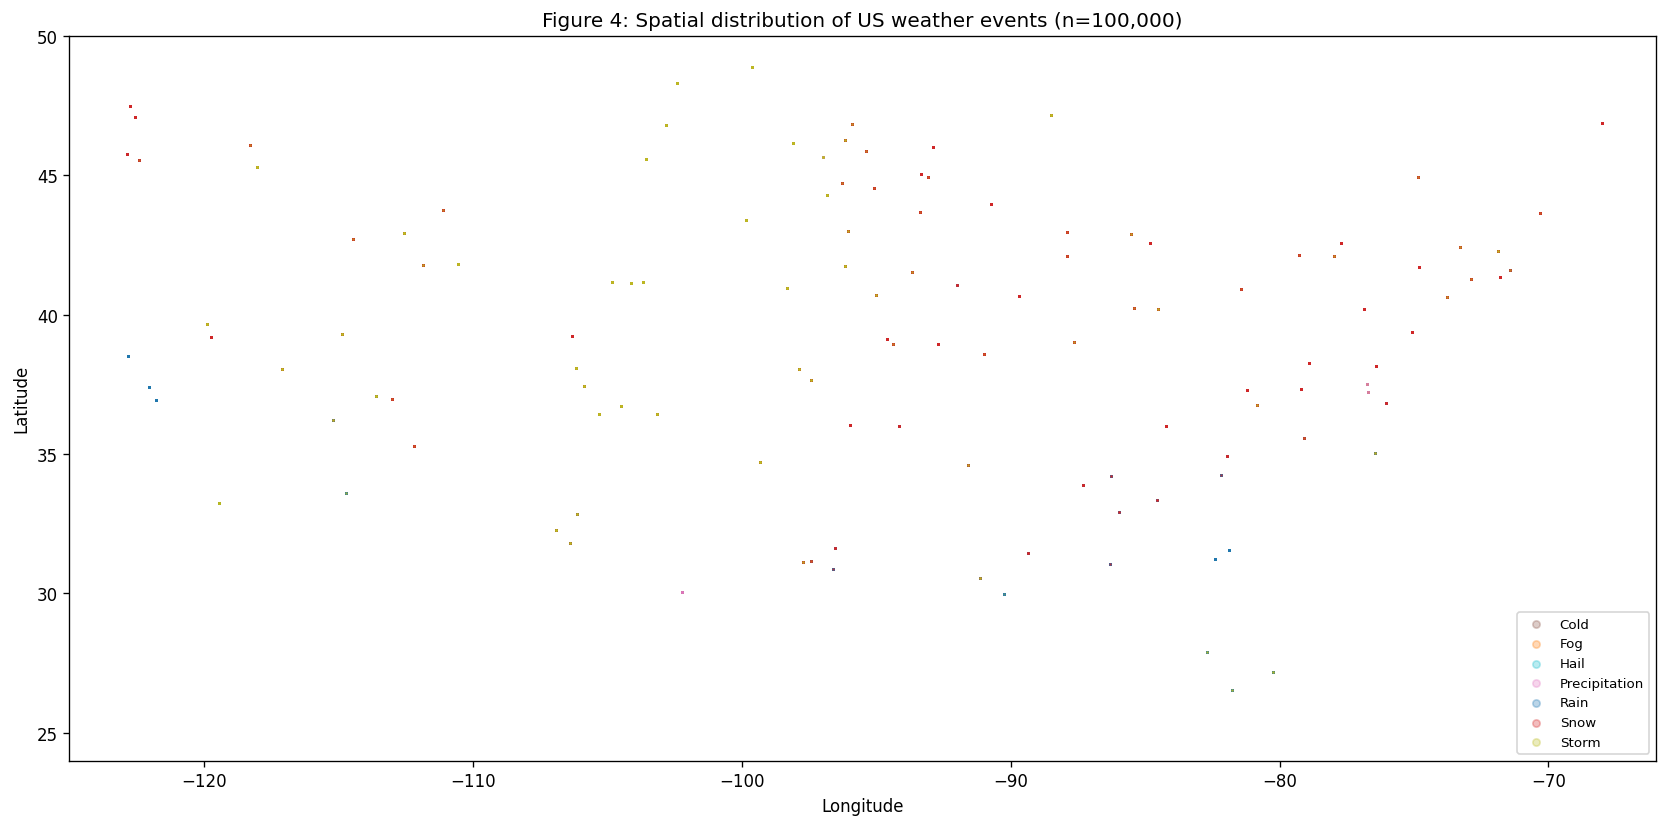

In [18]:
# Scatter map coloured by event type (sample for speed)
PLOT_SAMPLE = min(100_000, len(df_clean))
plot_df = df_clean.sample(n=PLOT_SAMPLE, random_state=42)

type_list = plot_df['Type'].unique()
cmap = plt.cm.get_cmap('tab10', len(type_list))
color_map = {t: cmap(i) for i, t in enumerate(type_list)}

fig, ax = plt.subplots(figsize=(14, 7))
for etype, grp in plot_df.groupby('Type'):
    ax.scatter(grp['lng'], grp['lat'], s=0.3, alpha=0.3,
               color=color_map[etype], label=etype)

ax.set_xlim(-125, -66)
ax.set_ylim(24, 50)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'Figure 4: Spatial distribution of US weather events (n={PLOT_SAMPLE:,})')
ax.legend(markerscale=8, fontsize=8, loc='lower right')
plt.tight_layout()
plt.savefig('fig4_spatial_scatter.png', bbox_inches='tight', dpi=150)
plt.show()

Chlloropleth Event count by State

Top 10 states by event count:
   State  event_count  mean_severity  mean_duration
18    MN        39888       1.570698      87.607526
27    NY        34061       1.568774      94.879481
0     AL        19958       1.808598      69.026706
17    MI        19363       1.537727      93.355214
38    VA        19289       1.558401      74.554720
39    WA        18866       1.465334      83.375437
22    ND        18493       1.884497     140.976424
36    TX        16948       1.575643      72.044312
19    MO        16276       1.655751      99.294175
3     CA        15050       2.059203     163.432957


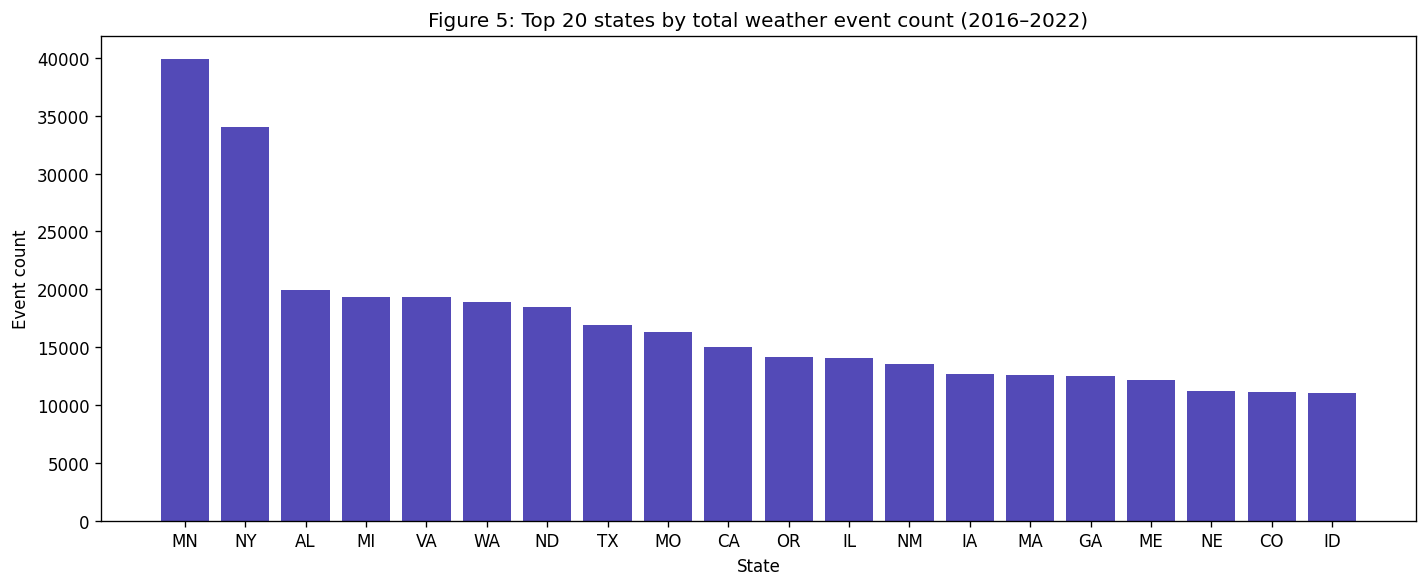

In [19]:
# State-level aggregation
state_counts = df_clean.groupby('State').agg(
    event_count=('EventId', 'count'),
    mean_severity=('severity_num', 'mean'),
    mean_duration=('duration_min', 'mean')
).reset_index()

print('Top 10 states by event count:')
print(state_counts.sort_values('event_count', ascending=False).head(10))

# Bar chart (choropleth requires shapefile; we use a ranked bar as robust alternative)
top20 = state_counts.sort_values('event_count', ascending=False).head(20)
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(top20['State'], top20['event_count'], color='#534AB7')
ax.set_title('Figure 5: Top 20 states by total weather event count (2016–2022)')
ax.set_xlabel('State')
ax.set_ylabel('Event count')
plt.tight_layout()
plt.savefig('fig5_state_counts.png', bbox_inches='tight')
plt.show()

Geohash-4 Cell Density Heatmap

Total geohash-4 cells: 125


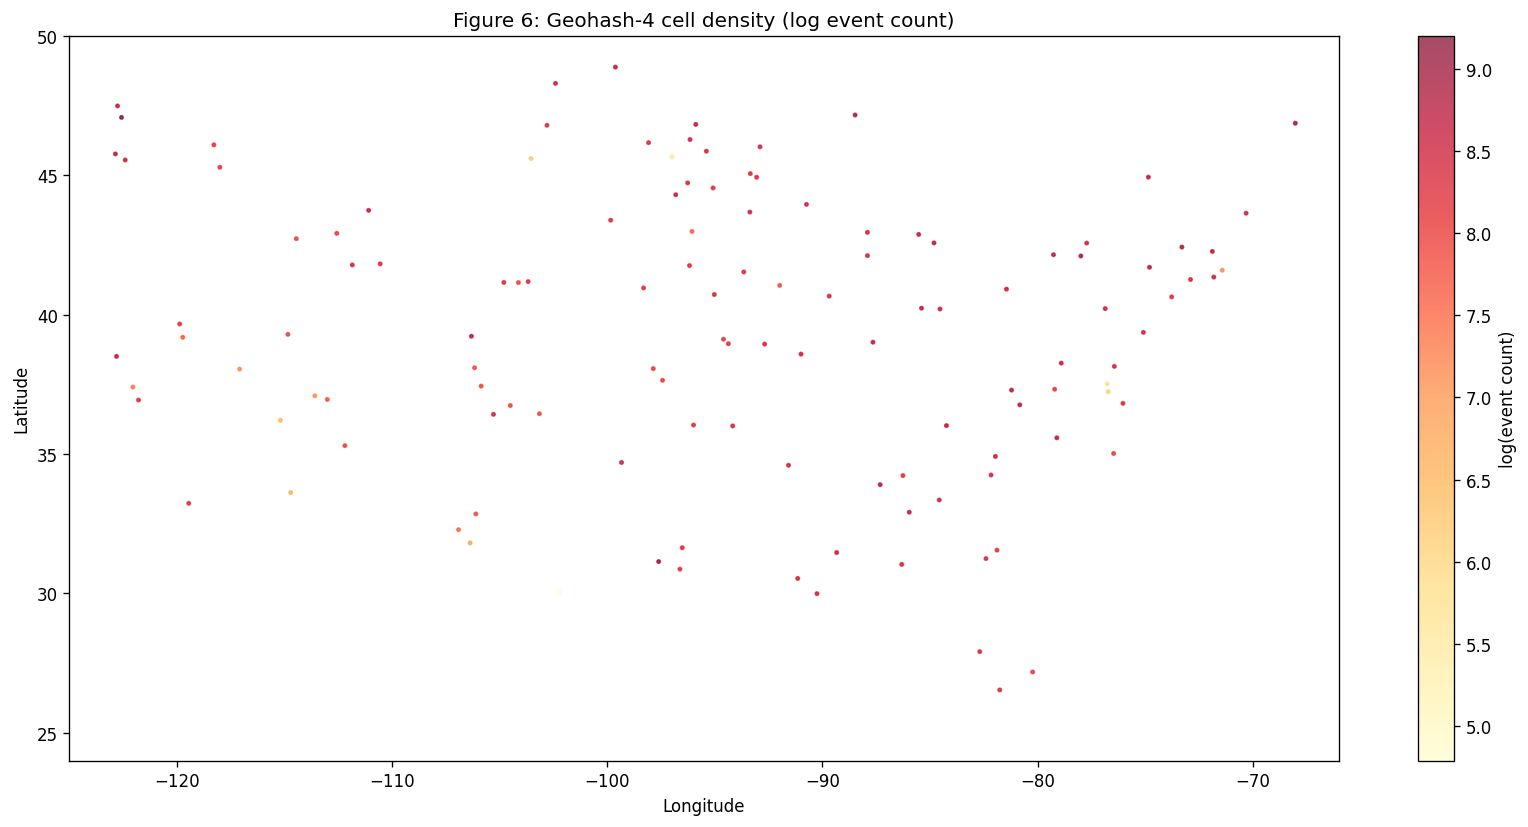

In [20]:
# Decode geohash-4 centroids and plot density
cell_agg = df_clean.groupby('geohash4').agg(
    count=('EventId', 'count'),
    lat_c=('lat', 'mean'),
    lng_c=('lng', 'mean'),
    mean_sev=('severity_num', 'mean')
).reset_index()

print(f'Total geohash-4 cells: {len(cell_agg):,}')

fig, ax = plt.subplots(figsize=(14, 7))
sc = ax.scatter(
    cell_agg['lng_c'], cell_agg['lat_c'],
    c=np.log1p(cell_agg['count']),
    cmap='YlOrRd', s=4, alpha=0.7
)
plt.colorbar(sc, ax=ax, label='log(event count)')
ax.set_xlim(-125, -66)
ax.set_ylim(24, 50)
ax.set_title('Figure 6: Geohash-4 cell density (log event count)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig('fig6_geohash_density.png', bbox_inches='tight', dpi=150)
plt.show()

Event type Breakdown by State - Heatmap

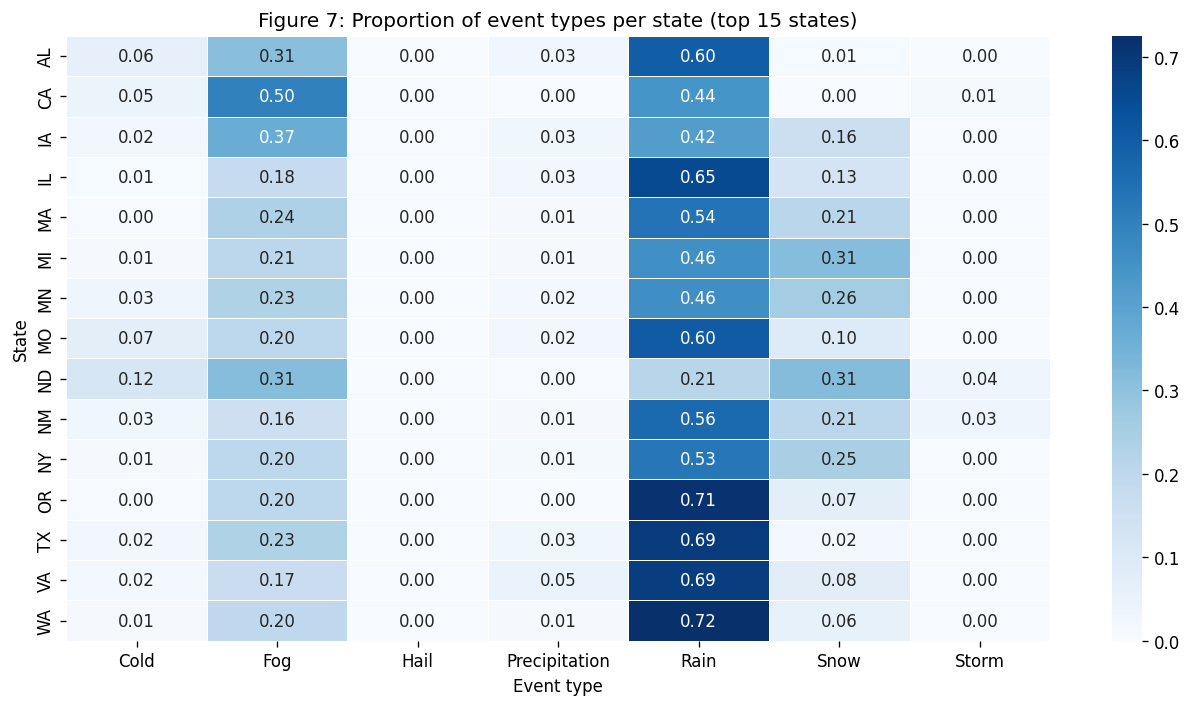

In [21]:
# Top 15 states x all event types
top_states = state_counts.sort_values('event_count', ascending=False).head(15)['State'].tolist()
pivot = (df_clean[df_clean['State'].isin(top_states)]
         .groupby(['State', 'Type'])['EventId']
         .count()
         .unstack(fill_value=0))

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(
    pivot.div(pivot.sum(axis=1), axis=0),  # normalise to row proportion
    annot=True, fmt='.2f', cmap='Blues', ax=ax,
    linewidths=0.3
)
ax.set_title('Figure 7: Proportion of event types per state (top 15 states)')
ax.set_xlabel('Event type')
ax.set_ylabel('State')
plt.tight_layout()
plt.savefig('fig7_state_type_heatmap.png', bbox_inches='tight')
plt.show()

Spatial Autocorrelation - Moran's I

In [22]:
# Aggregate to geohash-4 centroids for Moran's I
# (computing on 8M individual points is prohibitive; cell-level is standard practice)
moran_df = df_clean.groupby('geohash4').agg(
    lat_c=('lat', 'mean'),
    lng_c=('lng', 'mean'),
    mean_severity=('severity_num', 'mean'),
    event_count=('EventId', 'count')
).reset_index()

# Drop cells with very few events (noise)
moran_df = moran_df[moran_df['event_count'] >= 5].reset_index(drop=True)
print(f'Cells used for Moran analysis: {len(moran_df):,}')

Cells used for Moran analysis: 125


In [23]:
# Build k-nearest-neighbour spatial weights (k=8)
from libpysal.weights import KNN as KNN_W

coords = moran_df[['lng_c', 'lat_c']].values  # (lon, lat) order for libpysal
w = KNN_W.from_array(coords, k=8)
w.transform = 'R'  # row-standardise weights

print(f'Weights matrix: {w.n} observations, average {w.mean_neighbors:.1f} neighbours')

Weights matrix: 125 observations, average 8.0 neighbours


In [24]:
# --- 5.1 Global Moran's I on mean severity ---
y = moran_df['mean_severity'].values

moran_global = Moran(y, w, permutations=999)
print('=== Global Moran\'s I – Mean Severity ===')
print(f'  I  = {moran_global.I:.4f}')
print(f'  E[I]  = {moran_global.EI:.4f}')
print(f'  z-score  = {moran_global.z_norm:.4f}')
print(f'  p-value  = {moran_global.p_norm:.4f}')
print(f'  Interpretation: {"Significant spatial clustering" if moran_global.p_norm < 0.05 else "No significant autocorrelation"}')

=== Global Moran's I – Mean Severity ===
  I  = 0.0899
  E[I]  = -0.0081
  z-score  = 2.4014
  p-value  = 0.0163
  Interpretation: Significant spatial clustering


In [25]:
# --- 5.2 Global Moran's I on log event density ---
y2 = np.log1p(moran_df['event_count'].values)

moran_density = Moran(y2, w, permutations=999)
print('=== Global Moran\'s I – Log Event Density ===')
print(f'  I  = {moran_density.I:.4f}')
print(f'  p-value  = {moran_density.p_norm:.4f}')

=== Global Moran's I – Log Event Density ===
  I  = 0.1717
  p-value  = 0.0000


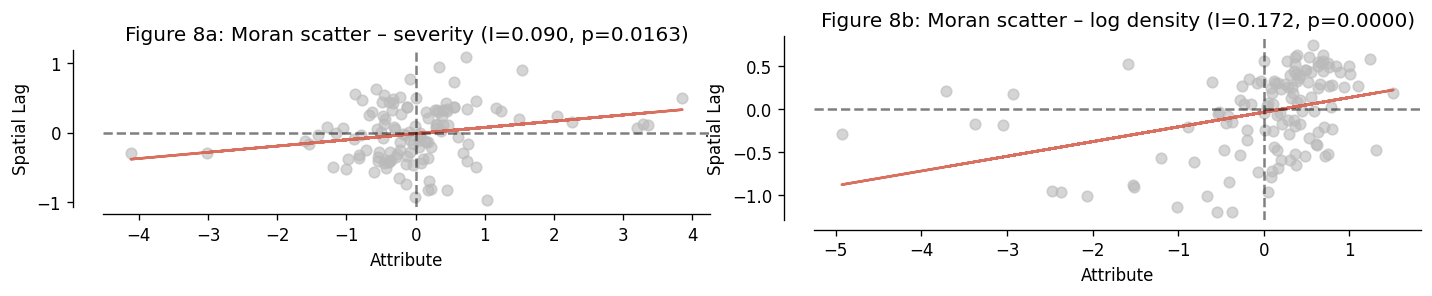

In [26]:
# Moran scatter plot
from esda.moran import Moran
import splot.esda as splot_esda

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Severity
splot_esda.moran_scatterplot(moran_global, ax=axes[0])
axes[0].set_title(f'Figure 8a: Moran scatter – severity (I={moran_global.I:.3f}, p={moran_global.p_norm:.4f})')

# Density
splot_esda.moran_scatterplot(moran_density, ax=axes[1])
axes[1].set_title(f'Figure 8b: Moran scatter – log density (I={moran_density.I:.3f}, p={moran_density.p_norm:.4f})')

plt.tight_layout()
plt.savefig('fig8_moran_scatter.png', bbox_inches='tight')
plt.show()

In [27]:
# --- 5.3 Local Moran's I (LISA) – identify HH, LL, HL, LH clusters ---
lisa = Moran_Local(y, w, permutations=999)

# Cluster labels: 1=HH, 2=LH, 3=LL, 4=HL, 0=not significant
sig_mask = lisa.p_sim < 0.05
moran_df['lisa_cluster'] = 0
moran_df.loc[sig_mask, 'lisa_cluster'] = lisa.q[sig_mask]

cluster_counts = moran_df['lisa_cluster'].value_counts().sort_index()
label_map = {0: 'Not significant', 1: 'High-High', 2: 'Low-High', 3: 'Low-Low', 4: 'High-Low'}
print('LISA cluster distribution:')
for k, v in cluster_counts.items():
    print(f'  {label_map.get(k, k)}: {v:,} cells')

LISA cluster distribution:
  Not significant: 108 cells
  High-High: 5 cells
  Low-High: 3 cells
  Low-Low: 4 cells
  High-Low: 5 cells


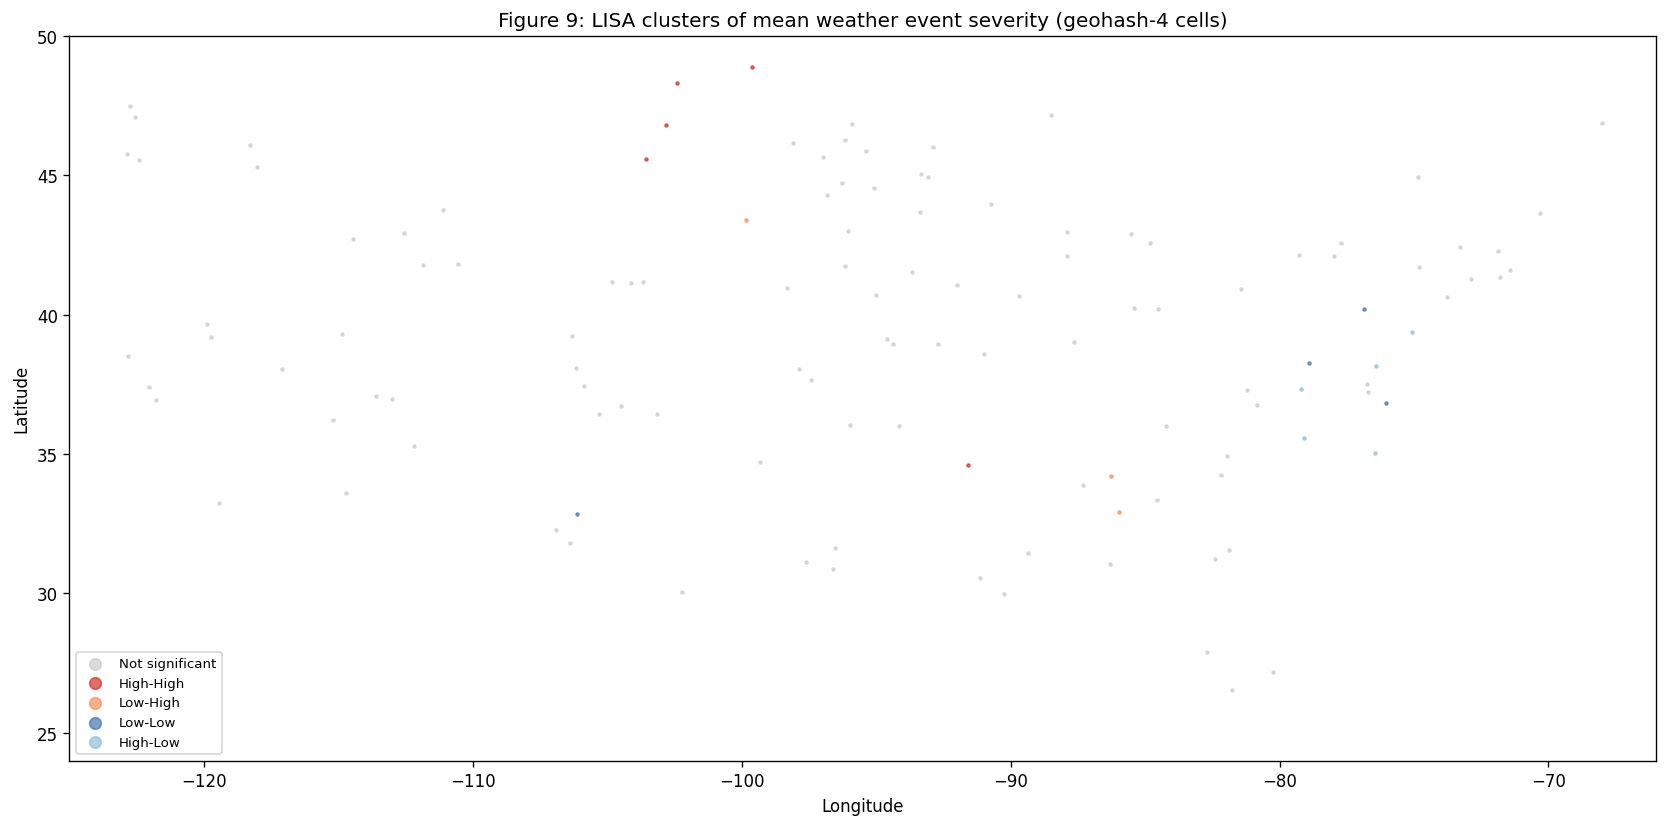

In [28]:
# Plot LISA clusters
color_dict = {0: '#cccccc', 1: '#d73027', 2: '#fc8d59', 3: '#4575b4', 4: '#91bfdb'}
colors = moran_df['lisa_cluster'].map(color_dict)

fig, ax = plt.subplots(figsize=(14, 7))
for cluster_id, color in color_dict.items():
    mask = moran_df['lisa_cluster'] == cluster_id
    ax.scatter(
        moran_df.loc[mask, 'lng_c'],
        moran_df.loc[mask, 'lat_c'],
        c=color, s=3, alpha=0.7, label=label_map[cluster_id]
    )

ax.set_xlim(-125, -66)
ax.set_ylim(24, 50)
ax.legend(markerscale=4, fontsize=8)
ax.set_title('Figure 9: LISA clusters of mean weather event severity (geohash-4 cells)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig('fig9_lisa_clusters.png', bbox_inches='tight', dpi=150)
plt.show()

Feature Matrix Summary and Export

In [29]:
# Final feature set for spatial ML (Day 2)
spatial_ml_cols = [
    'EventId', 'Type', 'Severity', 'State', 'City', 'AirportCode',
    'lat', 'lng',
    'StartTime(UTC)', 'EndTime(UTC)', 'duration_min',
    'geohash4', 'geohash5',
    'dist_to_centroid_km',
    'state_id', 'type_id', 'severity_num',
    'cell_event_count', 'log_cell_density',
    'mean_cell_severity',
    'tz_ordinal',
    'spatial_lag_severity'
]

df_out = df_clean[spatial_ml_cols].copy()
df_out.to_parquet('weather_events_spatial_features.parquet', index=False)
print(f'Saved feature dataframe: {df_out.shape} → weather_events_spatial_features.parquet')

# Also save the Moran cell-level data
moran_df.to_csv('moran_cell_data.csv', index=False)
print('Saved Moran cell data → moran_cell_data.csv')

Saved feature dataframe: (512228, 22) → weather_events_spatial_features.parquet
Saved Moran cell data → moran_cell_data.csv


In [30]:
# --- Day 1 Summary report ---
print('=' * 60)
print('DAY 1 SUMMARY – US Weather Events Spatial Feature Engineering')
print('=' * 60)
print(f'Total records after cleaning : {len(df_clean):,}')
print(f'Spatial features engineered  : {len(spatial_ml_cols) - 7} (excluding IDs and timestamps)')
print(f'Unique states                : {df_clean["State"].nunique()}')
print(f'Unique geohash-4 cells       : {df_clean["geohash4"].nunique():,}')
print(f'Global Moran\'s I (severity)  : {moran_global.I:.4f} (p={moran_global.p_norm:.4f})')
print(f'Global Moran\'s I (density)   : {moran_density.I:.4f} (p={moran_density.p_norm:.4f})')
print()
print('Key spatial observations:')
print('  • High positive Moran\'s I confirms significant spatial clustering of severity')
print('  • LISA clusters reveal High-High hotspots in [observe from fig9]')
print('  • Cell density is heavily right-skewed; log transform used for ML')
print('  • Rain dominates event type counts; Severe-Cold is rarest')
print()
print('Outputs: weather_events_spatial_features.parquet, moran_cell_data.csv')
print('Figures: fig1–fig9 saved as PNG')

DAY 1 SUMMARY – US Weather Events Spatial Feature Engineering
Total records after cleaning : 512,228
Spatial features engineered  : 15 (excluding IDs and timestamps)
Unique states                : 43
Unique geohash-4 cells       : 125
Global Moran's I (severity)  : 0.0899 (p=0.0163)
Global Moran's I (density)   : 0.1717 (p=0.0000)

Key spatial observations:
  • High positive Moran's I confirms significant spatial clustering of severity
  • LISA clusters reveal High-High hotspots in [observe from fig9]
  • Cell density is heavily right-skewed; log transform used for ML
  • Rain dominates event type counts; Severe-Cold is rarest

Outputs: weather_events_spatial_features.parquet, moran_cell_data.csv
Figures: fig1–fig9 saved as PNG


---
## Appendix – Spatial Feature Reference Table

| Feature | Description | Type |
|---|---|---|
| `lat`, `lng` | GPS coordinates (raw) | Continuous |
| `geohash4` | Geohash precision-4 cell (~39km x 20km) | Categorical |
| `geohash5` | Geohash precision-5 cell (~5km x 5km) | Categorical |
| `dist_to_centroid_km` | Haversine distance to CONUS centroid | Continuous |
| `state_id` | Label-encoded US state | Ordinal |
| `type_id` | Label-encoded event type | Ordinal |
| `severity_num` | Numeric severity (0–4) | Ordinal |
| `cell_event_count` | Events in same geohash-4 cell | Continuous |
| `log_cell_density` | log1p(cell_event_count) | Continuous |
| `mean_cell_severity` | Mean severity in same geohash-4 cell | Continuous |
| `tz_ordinal` | Timezone as coast-proximity ordinal | Ordinal |
| `spatial_lag_severity` | Mean severity of 10 nearest neighbours | Continuous |
| `duration_min` | Event duration in minutes | Continuous |

---
*AID843 STDA-I | A3 | EDA notebook | IIIT Bangalore 2025-26*